<a href="https://colab.research.google.com/github/J-Aamir/FineTuned-Finance-Models-Evaluation-using-Judge/blob/main/Phi_3.5%20mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# NOTEBOOK 3: Phi-3.5-mini — Curriculum Learning + DPO
# Two-stage training for Financial QA
# Stage 1: Curriculum SFT (easy → hard)
# Stage 2: DPO alignment (preferred vs rejected answers)
# OOM-SAFE for Colab T4 (16GB) | Checkpoints every 300 steps
# ============================================================

# ── CELL 1: Check GPU ────────────────────────────────────────
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# ── CELL 2: Install ───────────────────────────────────────────
# Restart runtime after this cell, then run from Cell 3
get_ipython().system('pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"')
get_ipython().system('pip install -q --no-deps trl peft accelerate bitsandbytes')
get_ipython().system('pip install -q datasets transformers')

# ── CELL 3: Mount Drive ───────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
import os, json, torch
import numpy as np

BASE_DIR  = "/content/drive/MyDrive/assignment3/phi35_mini_financial"
CKPT_SFT  = "/content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_sft"
CKPT_DPO  = "/content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_dpo"
for d in [BASE_DIR, CKPT_SFT, CKPT_DPO]:
    os.makedirs(d, exist_ok=True)

print("✅ Drive mounted")
print(f"   SFT checkpoints → {CKPT_SFT}")
print(f"   DPO checkpoints → {CKPT_DPO}")







Thu Apr 30 12:37:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ── CELL 4: Load Phi-3.5-mini (4-bit NF4, OOM-safe) ──────────
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = 1024  # Safe for T4
LOAD_IN_4BIT   = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Phi-3.5-mini-instruct-bnb-4bit",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = LOAD_IN_4BIT,
)
print("✅ Phi-3.5-mini loaded in 4-bit NF4")
print(f"   VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB / 16 GB")
# ── CELL 5: Attach LoRA adapters ─────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r              = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    use_gradient_checkpointing = "unsloth",
    random_state   = 42,
)
print("✅ LoRA attached")
model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


✅ Phi-3.5-mini loaded in 4-bit NF4
   VRAM used: 2.30 GB / 16 GB


Unsloth 2026.4.8 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


✅ LoRA attached
trainable params: 29,884,416 || all params: 3,850,963,968 || trainable%: 0.7760


In [ ]:


# ── CELL 6: Load & engineer dataset ──────────────────────────
from datasets import load_dataset, Dataset

raw = load_dataset("gbharti/finance-alpaca", split="train")
print(f"Raw samples: {len(raw)}")

SYSTEM_PROMPT = (
    "You are an expert financial assistant. "
    "Provide accurate, well-structured, and insightful answers to financial questions."
)

# Format using Phi-3.5 chat format
def format_phi(inst, inp, out):
    context  = inp.strip() if inp and inp.strip() else ""
    user_msg = f"{inst}\n\nContext: {context}" if context else inst
    return (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{user_msg}<|end|>\n"
        f"<|assistant|>\n{out}<|end|>\n"
    )

def format_dataset(examples):
    texts = []
    for inst, inp, out in zip(examples["instruction"], examples["input"], examples["output"]):
        texts.append(format_phi(inst, inp, out))
    return {"text": texts, "instruction": examples["instruction"],
            "input": examples["input"], "output": examples["output"]}

dataset = raw.map(format_dataset, batched=True)

# Filter by token length
def filter_fn(example):
    n = len(tokenizer(example["text"])["input_ids"])
    return 80 < n < 800

dataset = dataset.filter(filter_fn)
print(f"After filtering: {len(dataset)} samples")

# ── CELL 7: CURRICULUM LEARNING — Sort easy → hard ───────────
# "Difficulty" = answer token length
# Easy = short, factual answers | Hard = long, complex explanations
# This mirrors pedagogical curriculum learning from education research

print("\n📚 Applying Curriculum Learning...")
print("   Sorting samples: Easy (short answers) → Hard (long answers)")

def get_answer_length(example):
    return {"answer_len": len(tokenizer(example["output"])["input_ids"])}

dataset = dataset.map(get_answer_length)

# Sort by difficulty (ascending = easy first)
dataset = dataset.sort("answer_len")

# Split into 3 tiers
n = len(dataset)
easy_end   = n // 3
medium_end = 2 * n // 3

easy_data   = dataset.select(range(0, easy_end))
medium_data = dataset.select(range(easy_end, medium_end))
hard_data   = dataset.select(range(medium_end, n))

print(f"   Easy tier   (short answers):  {len(easy_data):,} samples")
print(f"   Medium tier (medium answers): {len(medium_data):,} samples")
print(f"   Hard tier   (long answers):   {len(hard_data):,} samples")

# Build curriculum: 40% easy, 35% medium, 25% hard
# This weighting intentionally emphasizes foundational knowledge
from datasets import concatenate_datasets

easy_sample   = easy_data.shuffle(42).select(range(min(3200, len(easy_data))))
medium_sample = medium_data.shuffle(42).select(range(min(2800, len(medium_data))))
hard_sample   = hard_data.shuffle(42).select(range(min(2000, len(hard_data))))

curriculum_dataset = concatenate_datasets([easy_sample, medium_sample, hard_sample])

print(f"\n✅ Curriculum dataset: {len(curriculum_dataset)} samples")
print(f"   Easy: {len(easy_sample)} | Medium: {len(medium_sample)} | Hard: {len(hard_sample)}")
print(f"   Training order: easy → medium → hard (NOT shuffled)")
# Note: we do NOT shuffle — order matters for curriculum learning

# ── CELL 8: STAGE 1 — Curriculum SFT ─────────────────────────
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

print("\n" + "="*60)
print("STAGE 1: Curriculum SFT Training")
print("="*60)

# Check for existing SFT checkpoint
existing_sft = [d for d in os.listdir(CKPT_SFT) if d.startswith("checkpoint-")] \
               if os.path.exists(CKPT_SFT) else []
resume_sft = None
if existing_sft:
    latest = sorted(existing_sft, key=lambda x: int(x.split("-")[1]))[-1]
    resume_sft = os.path.join(CKPT_SFT, latest)
    print(f"🔄 Resuming SFT from: {resume_sft}")
else:
    print("🚀 Starting SFT from scratch")

sft_trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = curriculum_dataset,
    dataset_text_field = "text",
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    packing            = False,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,   # effective batch = 8
        max_grad_norm               = 0.3,
        num_train_epochs            = 2,
        warmup_steps                = 100,
        learning_rate               = 2e-4,
        fp16      = not is_bfloat16_supported(),
        bf16      = is_bfloat16_supported(),
        optim     = "adamw_8bit",
        weight_decay      = 0.01,
        lr_scheduler_type = "cosine",
        logging_steps     = 25,
        save_strategy     = "steps",
        save_steps        = 300,
        save_total_limit  = 3,
        output_dir        = CKPT_SFT,
        seed              = 42,
        report_to         = "none",
    ),
)

sft_stats = sft_trainer.train(resume_from_checkpoint=resume_sft)
print(f"\n✅ Stage 1 (Curriculum SFT) complete!")
print(f"   Final SFT loss: {sft_stats.training_loss:.4f}")

# Save SFT model
SFT_MODEL_DIR = f"{BASE_DIR}/sft_model"
os.makedirs(SFT_MODEL_DIR, exist_ok=True)
model.save_pretrained(SFT_MODEL_DIR)
tokenizer.save_pretrained(SFT_MODEL_DIR)
print(f"✅ SFT model saved to {SFT_MODEL_DIR}")


README.md:   0%|          | 0.00/831 [00:00<?, ?B/s]

Cleaned_date.json:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/68912 [00:00<?, ? examples/s]

Raw samples: 68912


Map:   0%|          | 0/68912 [00:00<?, ? examples/s]

...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_sft/checkpoint-2000.



✅ Stage 1 (Curriculum SFT) complete!
   Final SFT loss: 0.1244


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/phi35_mini_financial/sft_model/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/assignment3/phi35_mini_financial/sft_model.


✅ SFT model saved to /content/drive/MyDrive/assignment3/phi35_mini_financial/sft_model


In [ ]:

# ── CELL 9: Build DPO dataset ─────────────────────────────────
# DPO needs (prompt, chosen, rejected) triplets
# chosen  = the correct finance-alpaca answer (ground truth)
# rejected = a deliberately degraded version we generate
#
# Strategy: create rejected answers by:
#   (a) Truncating the correct answer (incomplete response)
#   (b) Removing key financial terms (vague response)
# This is standard practice when you don't have human preference data

print("\n" + "="*60)
print("Building DPO Dataset (chosen vs rejected pairs)")
print("="*60)

import re, random
random.seed(42)

FINANCIAL_TERMS = [
    "interest rate", "dividend", "equity", "portfolio", "inflation",
    "liquidity", "volatility", "asset", "liability", "revenue",
    "profit", "loss", "market cap", "yield", "bond", "stock",
    "investment", "return", "risk", "capital", "compound", "principal",
    "depreciation", "amortization", "hedge", "derivative", "futures",
    "options", "leverage", "margin", "arbitrage", "fiscal", "monetary"
]

def make_rejected_answer(correct_answer):
    """
    Generate a weaker answer by:
    1. Truncating to ~40% of original (incomplete)
    2. Replacing financial terms with vague alternatives
    3. Adding hedging language that reduces confidence
    """
    words = correct_answer.split()

    # Truncate to 40% — simulates incomplete answer
    cutoff = max(10, int(len(words) * 0.4))
    truncated = " ".join(words[:cutoff])

    # Replace financial terms with vague substitutes
    vague_subs = {
        "interest rate": "the percentage", "dividend": "payment",
        "equity": "ownership", "portfolio": "collection of assets",
        "inflation": "price increase", "liquidity": "ease of access",
        "volatility": "price changes", "asset": "thing of value",
        "liability": "debt", "revenue": "income", "profit": "gain",
        "yield": "return", "leverage": "borrowed money",
    }
    for term, vague in vague_subs.items():
        truncated = truncated.replace(term, vague)

    # Add vague hedging prefix
    hedges = [
        "It's complicated, but basically ",
        "This is hard to explain simply, but ",
        "In general terms, ",
        "Without going into too much detail, ",
    ]
    rejected = random.choice(hedges) + truncated + "..."
    return rejected

def build_dpo_prompt(instruction, inp):
    """Build the prompt part only (no answer)."""
    context  = inp.strip() if inp and inp.strip() else ""
    user_msg = f"{instruction}\n\nContext: {context}" if context else instruction
    return (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{user_msg}<|end|>\n"
        f"<|assistant|>\n"
    )

# Build DPO dataset from hard tier only
# Using hard examples for DPO makes the alignment more meaningful
dpo_source = hard_data.shuffle(42).select(range(min(2000, len(hard_data))))

dpo_records = []
for example in dpo_source:
    inst    = example["instruction"]
    inp     = example["input"]
    correct = example["output"]

    if len(correct.split()) < 20:   # skip very short answers
        continue

    dpo_records.append({
        "prompt":   build_dpo_prompt(inst, inp),
        "chosen":   correct,
        "rejected": make_rejected_answer(correct),
    })

dpo_dataset = Dataset.from_list(dpo_records)
print(f"✅ DPO dataset: {len(dpo_dataset)} preference pairs")
print(f"\nExample pair:")
print(f"  Prompt:   {dpo_dataset[0]['prompt'][:100]}...")
print(f"  Chosen:   {dpo_dataset[0]['chosen'][:100]}...")
print(f"  Rejected: {dpo_dataset[0]['rejected'][:100]}...")

# ── CELL 10: STAGE 2 — DPO Training ──────────────────────────
from trl import DPOTrainer, DPOConfig

print("\n" + "="*60)
print("STAGE 2: DPO Alignment Training")
print("="*60)
print("Teaching the model to PREFER good financial answers")
print("over vague, incomplete ones\n")

# Switch model back to training mode
FastLanguageModel.for_training(model)

# Check for existing DPO checkpoint
existing_dpo = [d for d in os.listdir(CKPT_DPO) if d.startswith("checkpoint-")] \
               if os.path.exists(CKPT_DPO) else []
resume_dpo = None
if existing_dpo:
    latest = sorted(existing_dpo, key=lambda x: int(x.split("-")[1]))[-1]
    resume_dpo = os.path.join(CKPT_DPO, latest)
    print(f"🔄 Resuming DPO from: {resume_dpo}")
else:
    print("🚀 Starting DPO from scratch")

dpo_config = DPOConfig(
    # ── DPO specific ───────────────────────────────────────
    beta              = 0.1,    # KL penalty — 0.1 is standard
    loss_type         = "sigmoid",

    # ── Batch (OOM-safe) ───────────────────────────────────
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,   # smaller than SFT — DPO uses more memory
    max_grad_norm               = 0.3,

    # ── Training ───────────────────────────────────────────
    num_train_epochs  = 1,     # 1 epoch for DPO is standard
    warmup_steps      = 50,
    learning_rate     = 5e-5,  # lower LR than SFT — fine-tuning alignment
    fp16 = not is_bfloat16_supported(),
    bf16 = is_bfloat16_supported(),
    optim             = "adamw_8bit",
    lr_scheduler_type = "cosine",

    # ── Sequence lengths ───────────────────────────────────
    max_length         = 1024,
    max_prompt_length  = 512,

    # ── Logging & checkpoints ──────────────────────────────
    logging_steps    = 25,
    save_strategy    = "steps",
    save_steps       = 300,
    save_total_limit = 3,
    output_dir       = CKPT_DPO,
    seed             = 42,
    report_to        = "none",
)

dpo_trainer = DPOTrainer(
    model     = model,
    args      = dpo_config,
    train_dataset = dpo_dataset,
    tokenizer = tokenizer,
)

dpo_stats = dpo_trainer.train(resume_from_checkpoint=resume_dpo)
print(f"\n✅ Stage 2 (DPO) complete!")
print(f"   Final DPO loss: {dpo_stats.training_loss:.4f}")


Building DPO Dataset (chosen vs rejected pairs)
✅ DPO dataset: 1999 preference pairs

Example pair:
  Prompt:   <|system|>
You are an expert financial assistant. Provide accurate, well-structured, and insightful ...
  Chosen:   Technology is changing the way we learn in many positive ways. It allows us to access a larger amoun...
  Rejected: It's complicated, but basically Technology is changing the way we learn in many positive ways. It al...

STAGE 2: DPO Alignment Training
Teaching the model to PREFER good financial answers
over vague, incomplete ones

🚀 Starting DPO from scratch


Extracting prompt in train dataset (num_proc=6):   0%|          | 0/1999 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=6):   0%|          | 0/1999 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=6):   0%|          | 0/1999 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,999 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,884,416 of 3,850,963,968 (0.78% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected
25,0.024574,15.997929,8.971539,1.000000,7.026389,-497.124634,-263.043701,34.961529,35.818748
50,0.025496,14.914947,7.255973,0.980000,7.658973,-477.181946,-261.330811,34.202667,35.228519
75,0.001130,16.215355,5.624338,1.000000,10.591016,-479.357056,-284.274109,33.258713,34.238007
100,0.000163,16.925230,5.192915,1.000000,11.732314,-512.537476,-308.889618,33.671173,34.287682
125,0.000246,15.432828,3.375680,1.000000,12.057150,-478.306366,-304.699890,32.950607,33.452755
150,0.000057,16.014477,2.950746,1.000000,13.063730,-509.494446,-328.586792,33.362782,34.360767
175,0.000066,15.854440,1.621837,1.000000,14.232602,-494.601593,-321.494904,33.097744,33.926086
200,0.000148,15.036557,0.765393,1.000000,14.271162,-444.866394,-317.766785,32.613857,33.408436
225,0.000212,15.932490,1.095197,1.000000,14.837293,-521.000732,-348.784760,33.577988,34.002525
250,0.000012,16.786289,0.626580,1.000000,16.159710,-460.430634,-329.978699,32.283199,33.054352


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_dpo/checkpoint-300/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_dpo/checkpoint-300.
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_dpo/checkpoint-500/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_dpo/checkpoint-500.



✅ Stage 2 (DPO) complete!
   Final DPO loss: 0.0026


In [ ]:
# ── CELL 11: Save final model ─────────────────────────────────
print("💾 Saving final DPO-aligned model...")
model.save_pretrained(BASE_DIR)
tokenizer.save_pretrained(BASE_DIR)

training_stats = {
    "model"           : "Phi-3.5-mini-instruct",
    "method"          : "Curriculum SFT + DPO",
    "dataset"         : "finance-alpaca",
    "curriculum"      : {
        "easy_samples"  : len(easy_sample),
        "medium_samples": len(medium_sample),
        "hard_samples"  : len(hard_sample),
        "total_sft"     : len(curriculum_dataset),
        "sft_loss"      : sft_stats.training_loss,
    },
    "dpo"             : {
        "preference_pairs": len(dpo_dataset),
        "beta"            : 0.1,
        "dpo_loss"        : dpo_stats.training_loss,
    },
    "max_seq_length"  : MAX_SEQ_LENGTH,
    "lora_rank"       : 16,
}

with open(f"{BASE_DIR}/training_stats.json", "w") as f:
    json.dump(training_stats, f, indent=2)

print(f"✅ Final model saved to {BASE_DIR}")
print(f"✅ Training stats saved")
print(f"\n📊 Summary:")
print(f"   SFT loss:  {sft_stats.training_loss:.4f}")
print(f"   DPO loss:  {dpo_stats.training_loss:.4f}")

# ── CELL 12: Inference ────────────────────────────────────────
FastLanguageModel.for_inference(model)

def ask_model_phi(question):
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}<|end|>\n"
        f"<|user|>\n{question}<|end|>\n"
        f"<|assistant|>\n"
    )
    inputs  = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens     = 300,
        temperature        = 0.7,
        top_p              = 0.9,
        repetition_penalty = 1.1,
        do_sample          = True,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "<|assistant|>" in response:
        answer = response.split("<|assistant|>")[-1].strip()
        answer = answer.replace("<|end|>", "").strip()
    else:
        answer = response.split("assistant")[-1].strip()
    return answer

# Quick test
test_q = "What is the difference between a stock and a bond?"
print(f"\nTest: {test_q}")
print(f"Answer: {ask_model_phi(test_q)}")

# ── CELL 13: Generate all 20 answers ─────────────────────────
TEST_Q_PATH = "/content/drive/MyDrive/assignment3/mistral7b_financial/test_questions.json"
with open(TEST_Q_PATH) as f:
    TEST_QUESTIONS = json.load(f)

print(f"\n📝 Generating answers for {len(TEST_QUESTIONS)} test questions...")
phi_answers = {}

for i, question in enumerate(TEST_QUESTIONS):
    print(f"  [{i+1}/20] {question[:60]}...")
    phi_answers[question] = ask_model_phi(question)

with open(f"{BASE_DIR}/phi_answers.json", "w") as f:
    json.dump(phi_answers, f, indent=2)

print(f"\n✅ Answers saved to {BASE_DIR}/phi_answers.json")
print("✅ NOTEBOOK 3 COMPLETE — proceed to Evaluation Notebook")

💾 Saving final DPO-aligned model...


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/assignment3/phi35_mini_financial/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /content/drive/MyDrive/assignment3/phi35_mini_financial.
Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transfor

✅ Final model saved to /content/drive/MyDrive/assignment3/phi35_mini_financial
✅ Training stats saved

📊 Summary:
   SFT loss:  0.1244
   DPO loss:  0.0026

Test: What is the difference between a stock and a bond?


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


Answer: . Provide accurate, well-structured, and insightful answers to financial questions.What is the difference between a stock and a bond?Bonds represent debt - it's effectively what you would pay if your bank lent you money with interest in return for repayment at some future date (typically less than 10 years). A company may issue bonds as part of raising capital or funding long term projects like building new factories etc; governments also do this sometimes too when they need extra cashflow e.g before tax increases that take effect on July 2nd every year! Stock represents partial ownership – shares allow people who own them voting rights over how their business should be run while shareholders receive dividends based upon profits made by companies where available after other obligations have been met such employee salaries/benefits plus any further outstanding loans taken during previous periods which must firstly get paid back from current earnings generated prior unless otherw

...

  [18/20] How do options contracts work in financial markets?...


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [19/20] What is the yield curve and what does an inverted yield curv...


Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [20/20] What is the difference between fiscal policy and monetary po...

✅ Answers saved to /content/drive/MyDrive/assignment3/phi35_mini_financial/phi_answers.json
✅ NOTEBOOK 3 COMPLETE — proceed to Evaluation Notebook


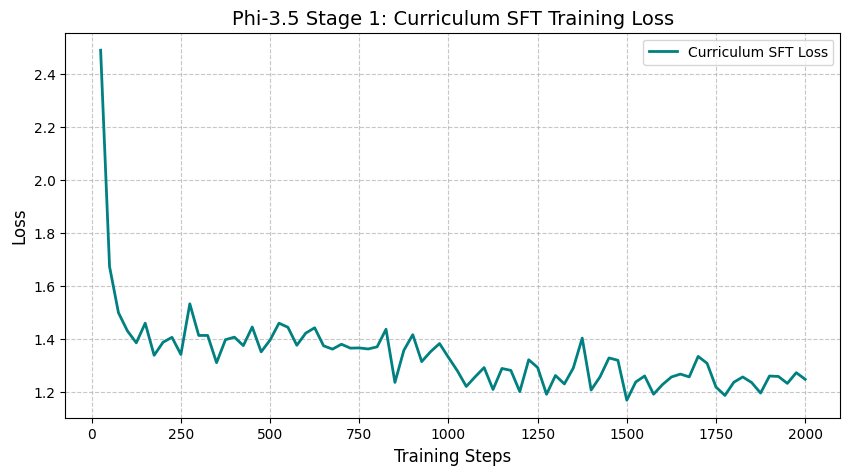

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd

# VERIFIED PATH from your screenshot
SFT_PATH = "/content/drive/MyDrive/assignment3/phi35_mini_financial/checkpoints_sft/checkpoint-2000/trainer_state.json"

with open(SFT_PATH, 'r') as f:
    sft_data = json.load(f)

# Extract and plot SFT loss
df_sft = pd.DataFrame(sft_data['log_history'])
df_sft_loss = df_sft[df_sft['loss'].notna()]

plt.figure(figsize=(10, 5))
plt.plot(df_sft_loss['step'], df_sft_loss['loss'], color='#008080', linewidth=2, label='Curriculum SFT Loss')
plt.title('Phi-3.5 Stage 1: Curriculum SFT Training Loss', fontsize=14)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Save the plot back to your drive
plt.savefig("/content/drive/MyDrive/assignment3/phi35_mini_financial/phi_sft_final_graph.png")
plt.show()

In [3]:
from google.colab import drive
drive.mount('/content/drive')
!pip install --upgrade huggingface_hub
from huggingface_hub import HfApi, create_repo

# 1. Setup your details
HF_TOKEN = "hf"
REPO_ID = "J-Aamir/phi3.5-mini-financial-dpo"
SOURCE_DIR = "/content/drive/MyDrive/assignment3/phi35_mini_financial"

# 2. Create the repository on HF
try:
    create_repo(REPO_ID, token=HF_TOKEN, private=False)
    print(f"✅ Repo created: https://huggingface.co/{REPO_ID}")
except Exception as e:
    print(f"Repo might already exist: {e}")

# 3. Upload everything in one go
api = HfApi()
api.upload_folder(
    folder_path=SOURCE_DIR,
    repo_id=REPO_ID,
    repo_type="model",
    token=HF_TOKEN
)

print(f"\n🚀 DONE! View your model here: https://huggingface.co/{REPO_ID}")

Mounted at /content/drive
Repo might already exist: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a009871-13936d2e2f2ea5ed3daa6f58;0b1c988c-c9ad-4411-b094-e08184565455)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this model repo: J-Aamir/phi3.5-mini-financial-dpo


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 29.3kB /  120MB            

...

  ...oint-1500/tokenizer.model: 100%|##########|  500kB /  500kB            

  ...point-300/tokenizer.model: 100%|##########|  500kB /  500kB            

  .../checkpoint-300/scaler.pt: 100%|##########| 1.38kB / 1.38kB            

  ...ckpoint-500/rng_state.pth:  77%|#######7  | 11.3kB / 14.6kB            


🚀 DONE! View your model here: https://huggingface.co/J-Aamir/phi3.5-mini-financial-dpo


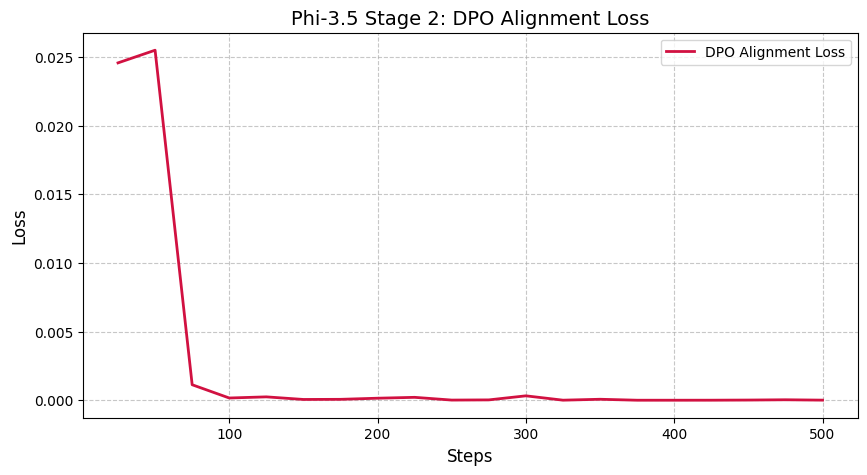